In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import  seaborn as sns

In [2]:
df = pd.read_csv("smartcart_customers.csv")

# data preprocessing

#### 1 handel misssing values

In [3]:
df["Income"] = df["Income"].fillna(df["Income"].median())

#### 2 feature engineering

In [4]:
#adding age feature
df["Age"] = 2026-df["Year_Birth"]

In [5]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,88,88,3,8,10,4,7,0,1,69
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,1,6,2,1,1,2,5,0,0,72
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,21,42,1,8,2,10,4,0,0,61
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,3,5,2,2,0,4,6,0,0,42
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,27,15,5,5,3,6,5,0,0,45


In [6]:
#customer tenure days

df["Dt_Customer"] = pd.to_datetime(df["Dt_Customer"], dayfirst=True)
reference_date = df["Dt_Customer"].max()
df["Customer_tenure_days"] =  (reference_date - df["Dt_Customer"]).dt.days


In [7]:
# Spending 

df["Total_Spending"] = df["MntWines"] + df["MntFruits"] + df["MntMeatProducts"] + df["MntFishProducts"] + df["MntSweetProducts"] + df["MntSweetProducts"] + df["MntGoldProds"] 

#total kids

df["Total_children"] = df["Kidhome"] + df["Teenhome"]

In [8]:
#EDUCATION

df["Education"].value_counts()

# reeplacing education values with 3 categories
#"Undergradute" , "Gradute" ,"Postgradute" 

df["Education"] = df["Education"].replace({
    "Basic": "Undergradute",
    "2n Cycle": "Undergradute",
    "Graduation": "Gradute",
    "PhD": "Postgradute",
    "Master": "Postgradute"
})

In [9]:
df["Living_With"] = df["Marital_Status"].replace({
    "Married": "Partner",
    "Together": "Partner",
    "Single": "Alone",
    "Divorced": "Alone",
    "Widow": "Alone",
    "Absurd": "Alone",
    "YOLO": "Alone"
})

In [10]:
cols=["ID","Year_Birth","Marital_Status","Kidhome",
      "Teenhome","Dt_Customer",
      "MntWines","MntFruits",
     "MntMeatProducts","MntFishProducts","MntSweetProducts",
      "MntGoldProds"]
df_cleaned = df.drop(columns=cols, axis=1)


In [11]:
cols=["Income","Recency","Response","Age","Total_Spending","Total_children"]

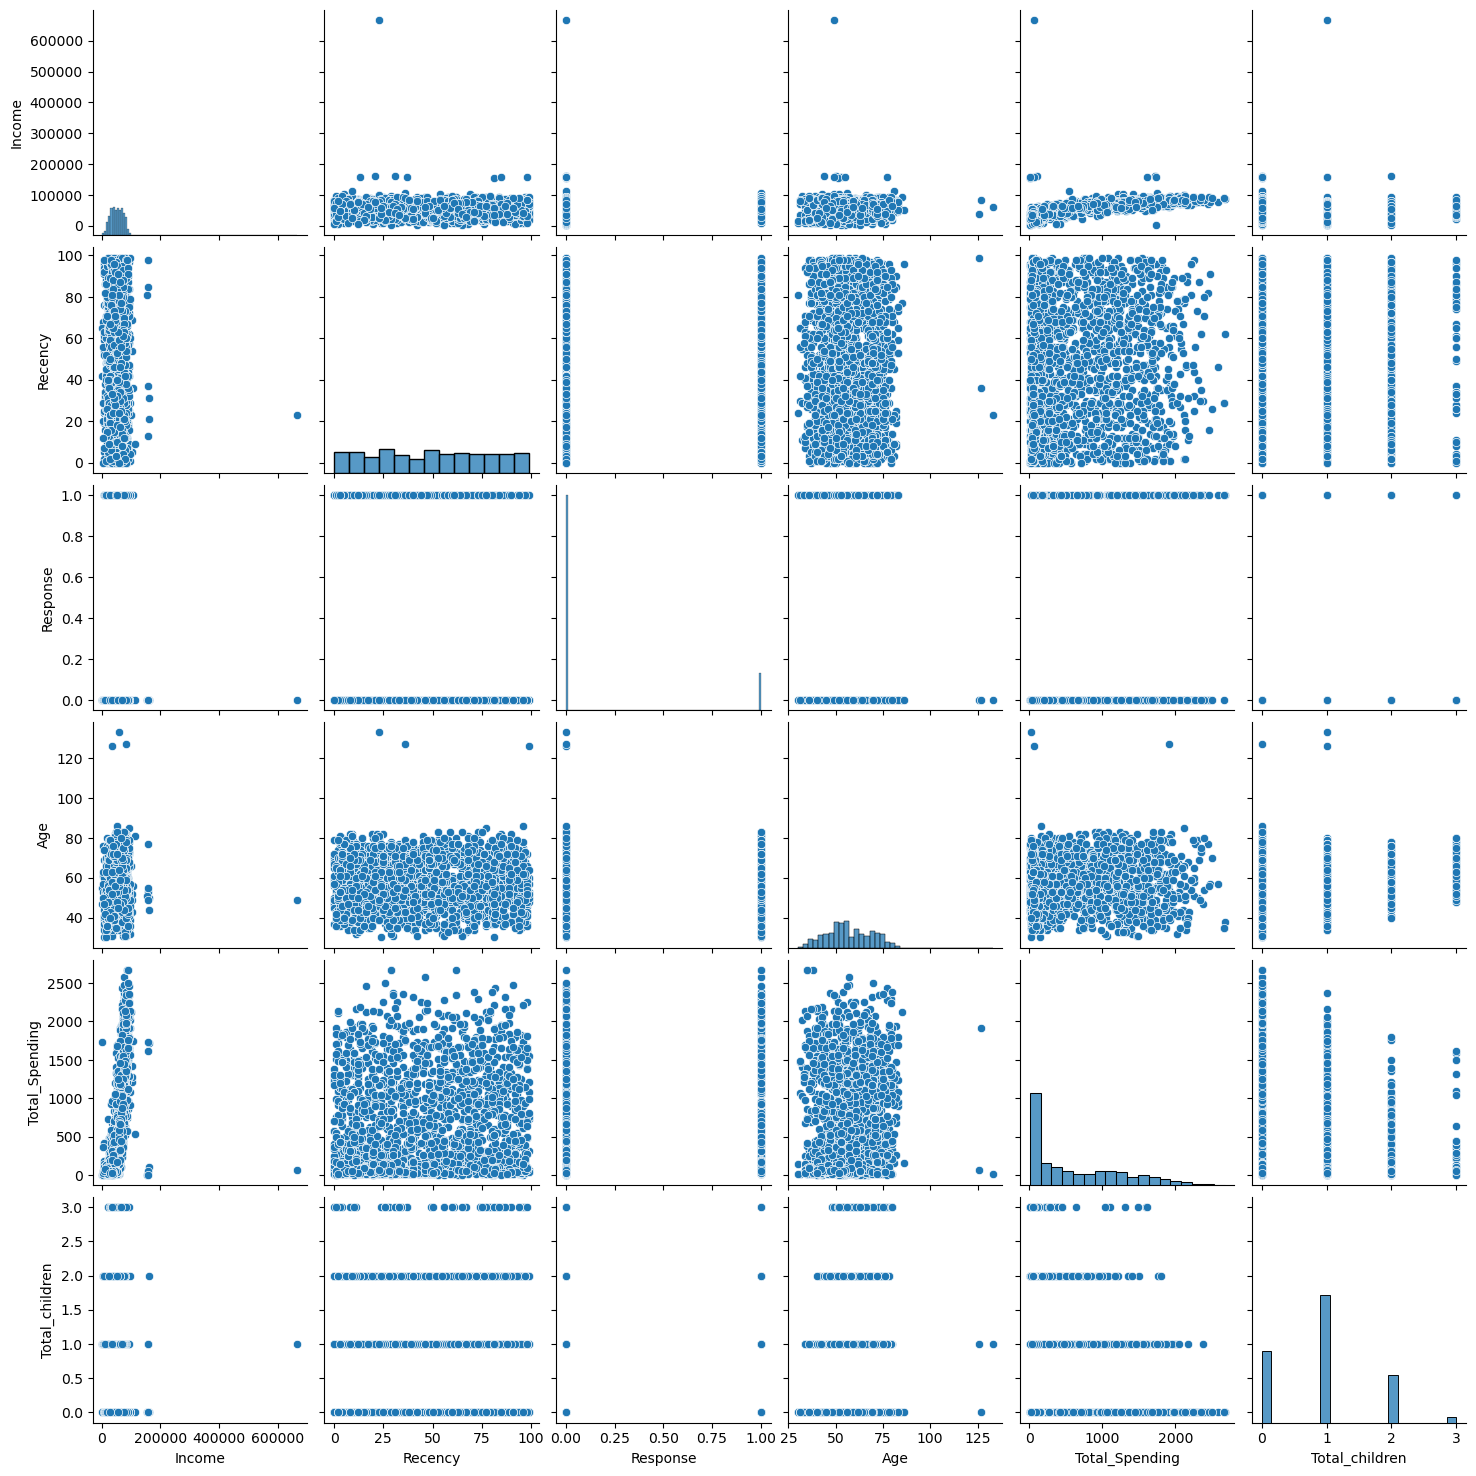

In [12]:
sns.pairplot(df_cleaned[cols])

In [13]:
print("data with outliers : " , len(df_cleaned))
df_cleaned = df_cleaned[ (df_cleaned["Age"]<90) ]
df_cleaned = df_cleaned[ (df_cleaned["Income"]<600_000) ]
print("data without outliers : " , len(df_cleaned))

data with outliers :  2240
data without outliers :  2236


### heatmap


In [14]:
corr = df_cleaned.corr(numeric_only = True)

<Axes: >

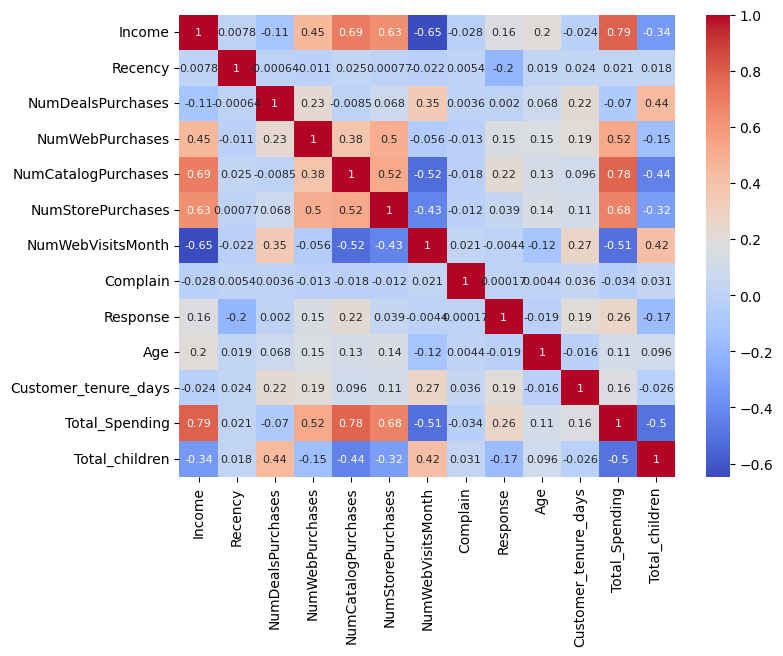

In [17]:
plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    annot=True,
    annot_kws={"size": 8},
    cmap="coolwarm"
)

### encoding

In [19]:
from sklearn.preprocessing import OneHotEncoder

In [24]:
ohe = OneHotEncoder()
cat_cols =["Education","Living_With"]
enc_cols=ohe.fit_transform(df_cleaned[cat_cols])

In [27]:
enc_df=pd.DataFrame(enc_cols.toarray(),columns=ohe.get_feature_names_out(cat_cols),index=df_cleaned.index)

In [28]:
enc_df.head()

,Education_Gradute,Education_Postgradute,Education_Undergradute,Living_With_Alone,Living_With_Partner
0,1.0,0.0,0.0,1.0,0.0
1,1.0,0.0,0.0,1.0,0.0
2,1.0,0.0,0.0,0.0,1.0
3,1.0,0.0,0.0,0.0,1.0
4,0.0,1.0,0.0,0.0,1.0


In [30]:
df_encoded = pd.concat([df_cleaned.drop(columns=cat_cols),enc_df], axis=1)

In [33]:
df_encoded.shape

(2236, 18)

### scaling

In [34]:
from sklearn.preprocessing import StandardScaler

In [35]:
X=df_encoded

scaler=StandardScaler()
X_scaled=scaler.fit_transform(X)

### visulize

In [36]:
from sklearn.decomposition import PCA

In [38]:
#2D

pca = PCA(n_components=2)
x_pca=pca.fit_transform(X_scaled)

array([0.23185128, 0.11385369])

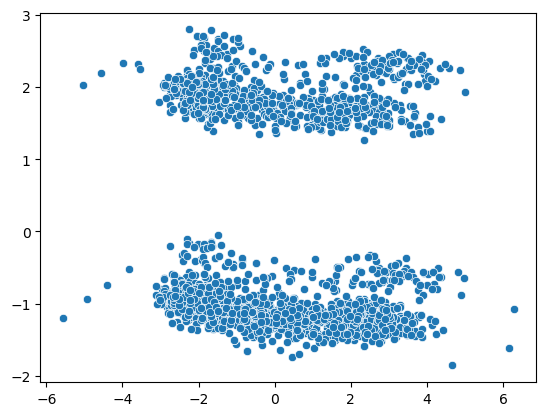

In [42]:
sns.scatterplot(x=x_pca[:,0],y=x_pca[:,1])
pca.explained_variance_ratio_

#array([0.23185128, 0.11385369])

In [49]:
#3D

pca = PCA(n_components=3)
X_pca=pca.fit_transform(X_scaled)
pca.explained_variance_ratio_

array([0.23185128, 0.11385369, 0.10403978])

Text(0.5, 0.92, '3D projection')

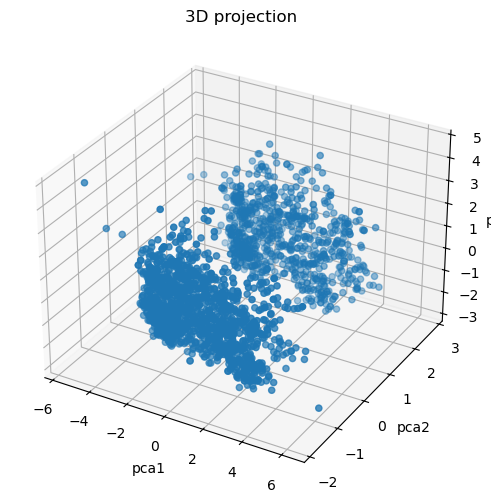

In [52]:
fig=plt.figure(figsize=(8,6))
ax=fig.add_subplot(111, projection= "3d")
ax.scatter(X_pca[:,0],X_pca[:,1],X_pca[:,2])

ax.set_xlabel("pca1")
ax.set_ylabel("pca2")
ax.set_zlabel("pca3")
ax.set_title("3D projection")

In [56]:
# analize k  value

from sklearn.cluster import KMeans
from sklearn.cluster import KMeans
from kneed import KneeLocator

# elbow mwthod
wcss = []
for k in range(1,11):
    km=KMeans(n_clusters=k, random_state=42)
    km.fit_predict(X_pca)
    wcss.append(km.inertia_)

In [57]:
knee= KneeLocator(range(1,11), wcss, curve="convex", direction="decreasing")
optimal_k=knee.elbow

In [58]:
optimal_k

np.int64(4)

Text(0, 0.5, 'silhouette_core')

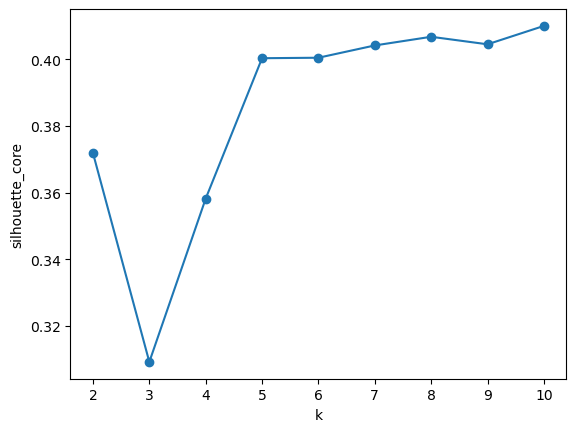

In [65]:
# silhouette score

from sklearn.metrics import silhouette_score
scores =[]

for k in range(2,11):
    kmeans=KMeans(n_clusters=k,random_state=42)
    labels= kmeans.fit_predict(X_pca)
    score=silhouette_score(X_pca,labels)
    scores.append(score)

#plot 
plt.plot(range(2,11),scores, marker="o")
plt.xlabel("k")
plt.ylabel("silhouette_core")

### clustering

In [69]:
#KMeans


kmeans=KMeans(n_clusters=4, random_state=42)
labels_kmeans=kmeans.fit_predict(X_pca)

Text(0.5, 0.92, '3D projection')

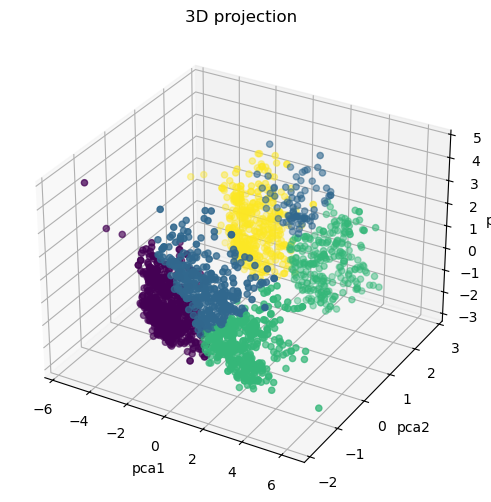

In [70]:
#cisualize
fig=plt.figure(figsize=(8,6))
ax=fig.add_subplot(111, projection= "3d")
ax.scatter(X_pca[:,0],X_pca[:,1],X_pca[:,2],c=labels_kmeans)

ax.set_xlabel("pca1")
ax.set_ylabel("pca2")
ax.set_zlabel("pca3")
ax.set_title("3D projection")

In [71]:
#Agglomerative clustering
from sklearn.cluster import AgglomerativeClustering

Text(0.5, 0.92, '3D projection')

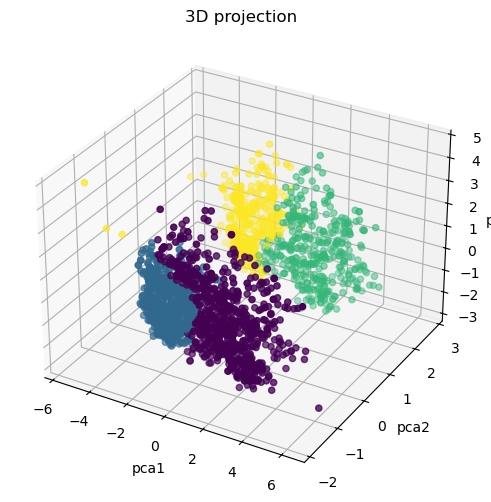

In [74]:
agg_clus=AgglomerativeClustering(n_clusters=4,linkage="ward")
agg_labels=agg_clus.fit_predict(X_pca)


#cisualize
fig=plt.figure(figsize=(8,6))
ax=fig.add_subplot(111, projection= "3d")
ax.scatter(X_pca[:,0],X_pca[:,1],X_pca[:,2],c=agg_labels)

ax.set_xlabel("pca1")
ax.set_ylabel("pca2")
ax.set_zlabel("pca3")
ax.set_title("3D projection")

# characterization and analizing each cluster

In [92]:
X["Clusters"]=agg_labels


<Axes: xlabel='Clusters', ylabel='count'>

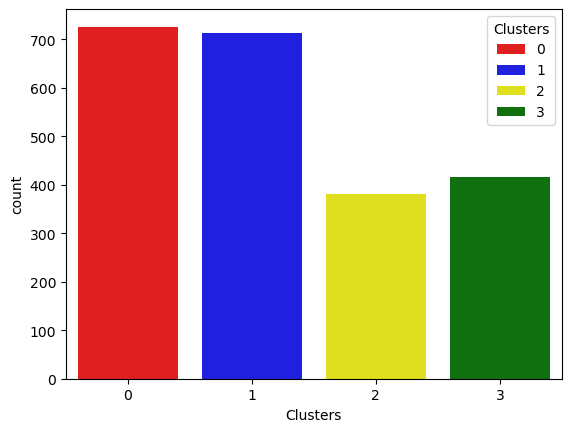

In [93]:
pal=["red","blue","yellow","green"]
sns.countplot(x=X["Clusters"],palette=pal,hue=X["Clusters"])

<Axes: xlabel='Total_Spending', ylabel='Income'>

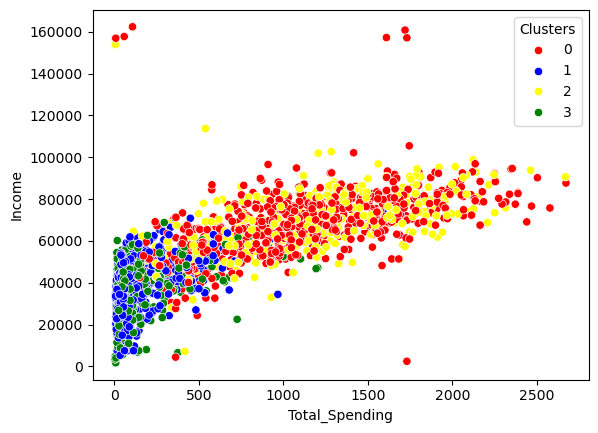

In [94]:
sns.scatterplot(x=X["Total_Spending"],y=X["Income"],hue=X["Clusters"],palette=pal)

In [95]:
cluster_summary= X.groupby("Clusters").mean()
print(cluster_summary)

                Income    Recency  NumDealsPurchases  NumWebPurchases  \
Clusters                                                                
0         67864.764463  48.498623           2.466942         5.681818   
1         35793.570827  49.553997           2.248247         2.476858   
2         69204.568421  51.189474           1.884211         5.676316   
3         36157.491607  47.553957           2.616307         2.618705   

          NumCatalogPurchases  NumStorePurchases  NumWebVisitsMonth  Complain  \
Clusters                                                                        
0                    4.618457           8.118457           4.118457  0.006887   
1                    0.645161           3.478261           6.493689  0.011220   
2                    4.760526           8.192105           3.855263  0.005263   
3                    0.798561           3.529976           6.733813  0.011990   

          Response        Age  Customer_tenure_days  Total_Spending  \
Clu